In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
import numpy as np
import pandas as pd
import sys
import tensorflow as tf
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 로지스틱 회귀분석(이진분류)
## 1. 데이터셋 생성 및 전처리

In [3]:
df = pd.read_csv('data/pima-indians-diabetes.csv',
                 comment='#',
                 header=None) # 0 ~ 16은 설명서
df.info() # 결측치 없음


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# 타겟 변수의 균형
df.iloc[:,-1].value_counts() # False = 500, True = 268

0    500
1    268
Name: 8, dtype: int64

In [5]:
df.head()
# X_data = df.iloc[,:-1].values

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# csv파일을 numpy로 읽어오기 : np.loadtxt(결측치가 없는 경우), np.genfromtxt(결측치 있을 경우)
dataset = np.loadtxt('data/pima-indians-diabetes.csv',encoding='utf-8', delimiter=',')
dataset.shape

(768, 9)

In [7]:
# 데이터 분할 : 학습데이터셋(모델학습) + 시험데이터셋(모델평가)
X_train = dataset[:700,:-1]
y_train = dataset[:700,-1]
X_test = dataset[700:,:-1]
y_test = dataset[700:,-1]
X_train.shape, y_train.shape, X_test.shape,y_test.shape

((700, 8), (700,), (68, 8), (68,))

## 2. 모델 생성

In [8]:
model = Sequential()
# 인풋변수 8개, 아웃풋변수 1개
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation = 'relu'))
model.add(Dense(units=64, activation = 'relu'))
model.add(Dense(units=16, activation = 'relu'))
model.add(Dense(units=1, activation = 'sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                288       
                                                                 
 dense_1 (Dense)             (None, 64)                2112      
                                                                 
 dense_2 (Dense)             (None, 16)                1040      
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3,457
Trainable params: 3,457
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [9]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['binary_accuracy']
)

## 4. 모델 학습

In [10]:
%%time
hist = model.fit(X_train, y_train, # 훈련데이터
                 epochs=200, # 학습회수
                 batch_size = 100, # 한 번에 읽어들이는 데이터의 양, 메모리가 여유가 있으면 batch_size를 크게 하여 학습 속도 향상을 도모할 수 있음
#                 validation_data=(X_train, y_train), 검증데이터
                 verbose = 0, # 로그 출력 여부(0 : 출력X, 1 : 간단하게 출력, 2 : 자세하게 출력)
#                  validation_split = 0.2, # 현재 훈련데이터에서 (20)퍼센트를 validation 데이터로 사용
                )

CPU times: total: 5.97 s
Wall time: 3.81 s


## 5. 모델 평가하기(학습과정 보기, 평가, 혼동행렬(교차표,성능평가표))

In [11]:
# hist.history
hist.history.keys() # loss binary_accuracy

dict_keys(['loss', 'binary_accuracy'])

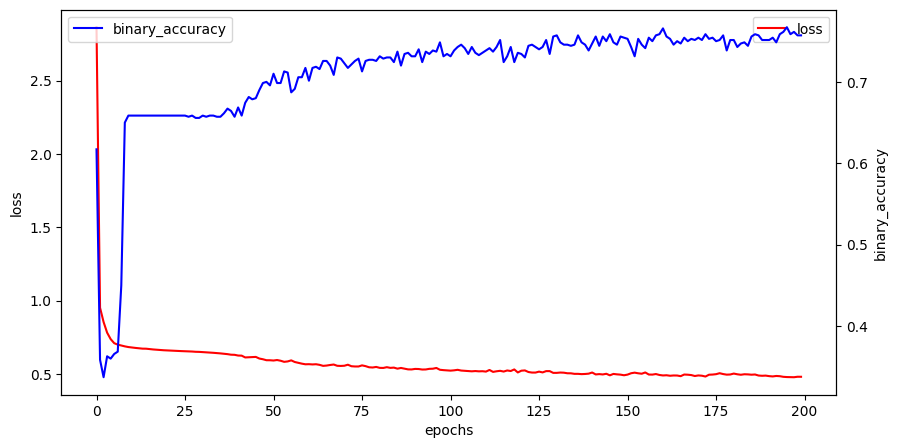

In [12]:
# 학습과정 표시(학습데이터에 대한 loss와 accuracy)
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], color='red', label = 'loss')
loss_ax.legend()
loss_ax.set_ylabel('loss')
loss_ax.set_xlabel('epochs')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['binary_accuracy'], color='blue', label = 'binary_accuracy')
acc_ax.set_ylabel('binary_accuracy')
acc_ax.legend()

In [13]:
# 모델 평가하기 -> test data set 활용
model.evaluate(X_test, y_test, verbose=2)

3/3 - 0s - loss: 0.6725 - binary_accuracy: 0.7353 - 208ms/epoch - 69ms/step


[0.6724666953086853, 0.7352941036224365]

### 혼동행렬
- 테스트 데이터 셋의 실제값과 예측값으로 작성된 교차표

In [14]:
y_test[:5]

array([0., 1., 1., 0., 0.])

In [15]:
# 실제값 : y_test(68개 데이터)
# 예측값 : y_hat
y_hat = (model.predict(X_test)>0.5).astype(float)

3/3 [==============================] - 0s 0s/step


In [16]:
TN = 0 # 0을 0으로 예측한 경우의 수(T)
FP = 0 # 0을 1로 예측한 경우의 수(F)
FN = 0 # 1을 0으로 예측한 경우의 수(F)
TP = 0 # 1을 1로 예측한 경우의 수(T)
print(y_test.shape, y_hat.shape)
for y, h in zip(y_test,y_hat.reshape(-1)) :
    if y == 0 and h == 0 :
        TN +=1
    elif y==0 and h==1 :
        FP +=1
    elif y==1 and h == 0 :
        FN +=1
    else :
        TP +=1
print(TN, TP)
print(FN, FP)

(68,) (68, 1)
37 13
14 4


In [17]:
# 라이브러리로 해결하는 교차표 1. pandas
ctab = pd.crosstab(y_test, # 실제값 1차원
                   y_hat.reshape(-1), # 예측값 1차원
                  )
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
ctab
pd.crosstab(y_test, # 실제값 1차원
            y_hat.reshape(-1), # 예측값 1차원
            rownames=['실제값'],
           colnames=['예측값'])

예측값,0.0,1.0
실제값,,
0.0,37,4
1.0,14,13


In [18]:
# 라이브러리로 해결하는 교차표(혼동행렬) 2. sklearn.metrics.confusion_matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,
                y_hat.reshape(-1))

array([[37,  4],
       [14, 13]], dtype=int64)

In [19]:
# accuracy
accuracy = (TN+TP)/(TN+TP+FN+FP)
recall = (TP)/(TP+FN)
precision = (TP)/(TP+FP)
print('accuracy :',accuracy)
print('recall :',recall)
print('precision :',precision)

accuracy : 0.7352941176470589
recall : 0.48148148148148145
precision : 0.7647058823529411


## 6. 모델 사용

In [20]:
X_test[0] # 1차원 데이터

array([  2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
        26.   ])

In [21]:
int(model.predict(np.array([[2, 122, 76, 27, 200 , 35 , 0.483, 26]]))>=0.5)

1/1 [==============================] - 0s 27ms/step


0

In [22]:
(model.predict([[2, 122, 76, 27, 200 , 35 , 0.483, 26],
              [0, 122, 76, 27, 200 , 35 , 0.483, 26]])).round()

1/1 [==============================] - 0s 55ms/step


array([[0.],
       [0.]], dtype=float32)

# 분류분석
1. 데이터셋 생성 및 전처리 : 훈련셋(600), 검증셋(100), 시험셋(68개)
2. 모델생성(input : 8개, output : 2(당뇨병이거나(1) 당뇨병이 아니거나(0)) : 출력층 softmax => 출력 합을 1로
     * model.summary() => 파라미터수와 메모리 체크
3. 모델 학습과정 설정 : loss='categorical_crossentropy' , metrics=['accuracy'], optimizer = 'adam' // metrics에서 recall이나 precsion을 쓰려면 import
4. 모델 학습 : 훈련셋과 검증셋
5. 모델 평가하기 : 그래프(hist.history) -> loss, accuracy, val_loss, val_accuracy, 평가 -> model.evaluate(x_test, y_test), 교차표 -> 테스트셋(평가결과로)
6. 모델 저장 및 사용하기 : model.predict()
    * array([99.2, 0.8]) 형태로 결과 반환, 여기서 prediction.argmax()

## 1. 데이터셋 생성 및 전처리

In [23]:
dataset = np.loadtxt('data/pima-indians-diabetes.csv', delimiter=',', encoding = 'utf-8')
dataset.shape

(768, 9)

In [24]:
X_train = dataset[:600,:-1]
y_train = dataset[:600,-1:]
X_val = dataset[600:700,:-1]
y_val = dataset[600:700,-1:]
X_test = dataset[700:,:-1]
y_test = dataset[700:,-1:]

In [25]:
X_train.shape,y_train.shape,X_val.shape,y_val.shape,X_test.shape, y_test.shape

((600, 8), (600, 1), (100, 8), (100, 1), (68, 8), (68, 1))

In [26]:
# 타겟변수의 OneHotEncoding -> 분류분석
Y_train = utils.to_categorical(y_train)
# y_train.shape, Y_train.shape
Y_val = utils.to_categorical(y_val)
Y_test = utils.to_categorical(y_test)
Y_train.shape, Y_val.shape, Y_test.shape, 

((600, 2), (100, 2), (68, 2))

## 2. 모델 생성
- Input 8, Output 2
- 과적합 줄이는 단계 추가 : dropout

In [27]:
from tensorflow.keras.layers import Dropout
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation = 'relu'))
model.add(Dropout(0.2)) # 과적합을 해결하고자 두루뭉실하게 넘김
model.add(Dense(units=64, activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(units=16, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units=8, activation = 'relu'))
model.add(Dense(units=2, activation = 'softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 32)                288       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 64)                2112      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_6 (Dense)             (None, 16)                1040      
                                                                 
 dropout_2 (Dropout)         (None, 16)                0         
                                                                 
 dense_7 (Dense)             (None, 8)                

## 3. 학습과정 설정

In [28]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics=['accuracy'])

## 4. 모델 학습

In [29]:
%%time
hist = model.fit(X_train,Y_train,
                 epochs=500,
                 validation_data=(X_val,Y_val),
                 verbose=1,
#                 batch_size=300,
                )

Epoch 1/500
19/19 [==============================] - 1s 16ms/step - loss: 6.7097 - accuracy: 0.5133 - val_loss: 0.8557 - val_accuracy: 0.5900
Epoch 2/500
19/19 [==============================] - 0s 4ms/step - loss: 3.0847 - accuracy: 0.5150 - val_loss: 0.9353 - val_accuracy: 0.4700
Epoch 3/500
19/19 [==============================] - 0s 4ms/step - loss: 1.6321 - accuracy: 0.5883 - val_loss: 0.7154 - val_accuracy: 0.5700
Epoch 4/500
19/19 [==============================] - 0s 4ms/step - loss: 1.4401 - accuracy: 0.5700 - val_loss: 0.7670 - val_accuracy: 0.5100
Epoch 5/500
19/19 [==============================] - 0s 3ms/step - loss: 1.1594 - accuracy: 0.5817 - val_loss: 0.7015 - val_accuracy: 0.6000
Epoch 6/500
19/19 [==============================] - 0s 4ms/step - loss: 0.9267 - accuracy: 0.6083 - val_loss: 0.6703 - val_accuracy: 0.5800
Epoch 7/500
19/19 [==============================] - 0s 4ms/step - loss: 0.9100 - accuracy: 0.5917 - val_loss: 0.6991 - val_accuracy: 0.4900
Epoch 8/500


Epoch 59/500
19/19 [==============================] - 0s 4ms/step - loss: 0.6281 - accuracy: 0.6767 - val_loss: 0.6098 - val_accuracy: 0.7000
Epoch 60/500
19/19 [==============================] - 0s 4ms/step - loss: 0.6262 - accuracy: 0.6733 - val_loss: 0.5996 - val_accuracy: 0.7000
Epoch 61/500
19/19 [==============================] - 0s 4ms/step - loss: 0.6034 - accuracy: 0.6883 - val_loss: 0.5937 - val_accuracy: 0.6900
Epoch 62/500
19/19 [==============================] - 0s 4ms/step - loss: 0.6135 - accuracy: 0.6700 - val_loss: 0.6004 - val_accuracy: 0.7000
Epoch 63/500
19/19 [==============================] - 0s 5ms/step - loss: 0.6208 - accuracy: 0.6867 - val_loss: 0.5905 - val_accuracy: 0.7100
Epoch 64/500
19/19 [==============================] - 0s 3ms/step - loss: 0.6213 - accuracy: 0.6600 - val_loss: 0.5945 - val_accuracy: 0.7000
Epoch 65/500
19/19 [==============================] - 0s 4ms/step - loss: 0.6195 - accuracy: 0.6800 - val_loss: 0.5942 - val_accuracy: 0.7100
Epoch 

19/19 [==============================] - 0s 4ms/step - loss: 0.5808 - accuracy: 0.6950 - val_loss: 0.5685 - val_accuracy: 0.7100
Epoch 174/500
19/19 [==============================] - 0s 3ms/step - loss: 0.5646 - accuracy: 0.7300 - val_loss: 0.5553 - val_accuracy: 0.7200
Epoch 175/500
19/19 [==============================] - 0s 4ms/step - loss: 0.5550 - accuracy: 0.7233 - val_loss: 0.5634 - val_accuracy: 0.7100
Epoch 176/500
19/19 [==============================] - 0s 3ms/step - loss: 0.5402 - accuracy: 0.7450 - val_loss: 0.5659 - val_accuracy: 0.7100
Epoch 177/500
19/19 [==============================] - 0s 3ms/step - loss: 0.5477 - accuracy: 0.7183 - val_loss: 0.5282 - val_accuracy: 0.7300
Epoch 178/500
19/19 [==============================] - 0s 4ms/step - loss: 0.5525 - accuracy: 0.7433 - val_loss: 0.5259 - val_accuracy: 0.7200
Epoch 179/500
19/19 [==============================] - 0s 4ms/step - loss: 0.5415 - accuracy: 0.7350 - val_loss: 0.5601 - val_accuracy: 0.7100
Epoch 180/500

19/19 [==============================] - 0s 4ms/step - loss: 0.5287 - accuracy: 0.7500 - val_loss: 0.5448 - val_accuracy: 0.7100
Epoch 288/500
19/19 [==============================] - 0s 4ms/step - loss: 0.5133 - accuracy: 0.7567 - val_loss: 0.5280 - val_accuracy: 0.7000
Epoch 289/500
19/19 [==============================] - 0s 3ms/step - loss: 0.5263 - accuracy: 0.7317 - val_loss: 0.5473 - val_accuracy: 0.7000
Epoch 290/500
19/19 [==============================] - 0s 4ms/step - loss: 0.5204 - accuracy: 0.7483 - val_loss: 0.5175 - val_accuracy: 0.7100
Epoch 291/500
19/19 [==============================] - 0s 4ms/step - loss: 0.4977 - accuracy: 0.7450 - val_loss: 0.5198 - val_accuracy: 0.7100
Epoch 292/500
19/19 [==============================] - 0s 4ms/step - loss: 0.5107 - accuracy: 0.7433 - val_loss: 0.5473 - val_accuracy: 0.7000
Epoch 293/500
19/19 [==============================] - 0s 4ms/step - loss: 0.5092 - accuracy: 0.7633 - val_loss: 0.5289 - val_accuracy: 0.7100
Epoch 294/500

19/19 [==============================] - 0s 4ms/step - loss: 0.5065 - accuracy: 0.7433 - val_loss: 0.5363 - val_accuracy: 0.7000
Epoch 402/500
19/19 [==============================] - 0s 4ms/step - loss: 0.4882 - accuracy: 0.7617 - val_loss: 0.5507 - val_accuracy: 0.7000
Epoch 403/500
19/19 [==============================] - 0s 3ms/step - loss: 0.4920 - accuracy: 0.7467 - val_loss: 0.5257 - val_accuracy: 0.7100
Epoch 404/500
19/19 [==============================] - 0s 3ms/step - loss: 0.4767 - accuracy: 0.7717 - val_loss: 0.5679 - val_accuracy: 0.6900
Epoch 405/500
19/19 [==============================] - 0s 4ms/step - loss: 0.4755 - accuracy: 0.7633 - val_loss: 0.5429 - val_accuracy: 0.7100
Epoch 406/500
19/19 [==============================] - 0s 4ms/step - loss: 0.4892 - accuracy: 0.7433 - val_loss: 0.5254 - val_accuracy: 0.7000
Epoch 407/500
19/19 [==============================] - 0s 4ms/step - loss: 0.4951 - accuracy: 0.7533 - val_loss: 0.5345 - val_accuracy: 0.7000
Epoch 408/500

## 5. 학습과정 살펴보기

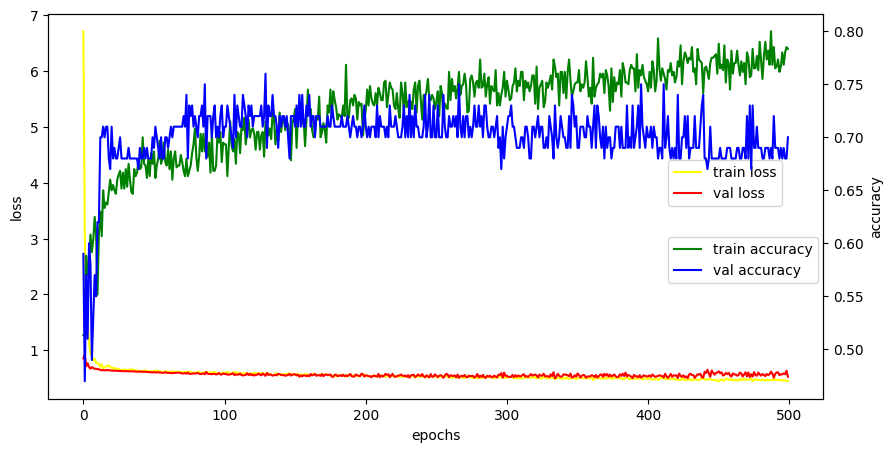

In [30]:
# hist.history.keys() # loss accuracy val_loss val_accuracy
fig, loss_ax = plt.subplots(figsize = (10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow', label='train loss')
loss_ax.plot(hist.history.get('val_loss'), color='red', label='val loss')
loss_ax.legend(loc=(0.8,0.5))
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), color='green', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), color='blue', label='val accuracy')
acc_ax.legend(loc=(0.8,0.3))
acc_ax.set_ylabel('accuracy')
plt.show()

## 6. 모델 평가하기

In [31]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0) # loss : 0.6163477897644043, accuracy : 0.6911764740943909
print('loss :',loss, 'accuracy :', accuracy)

loss : 0.6691920757293701 accuracy : 0.6323529481887817


## 7. 교차표

In [32]:
Y_test.argmax(axis=1) # 실제값 y_test의 1차원 형태

array([0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0], dtype=int64)

In [33]:
y_hat = model.predict(X_test).argmax(axis=1)
y_hat

3/3 [==============================] - 0s 8ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0], dtype=int64)

In [34]:
pd.crosstab(Y_test.argmax(axis=1),
           y_hat,
           rownames = ['실제값'],
           colnames = ['예측값'])

예측값,0,1
실제값,,
0,40,1
1,24,3


In [35]:
confusion_matrix(Y_test.argmax(axis=1),y_hat)

array([[40,  1],
       [24,  3]], dtype=int64)

## 8. 모델 저장 및 사용하기

In [36]:
# model.save('data/06_pima.h5')
from tensorflow.keras.models import save_model, load_model
# save_model(model,'model/06_pima.h5')

In [37]:
model2 = load_model('model/06_pima.h5')

In [38]:
pred = model2.predict(np.array([X_test[0],X_test[50]]))
pred.argmax(axis=1)

1/1 [==============================] - 0s 80ms/step


array([0, 0], dtype=int64)

In [39]:
np.argmax(pred, axis=1)

array([0, 0], dtype=int64)